Accuracy: 0.806
Precision: 0.544
Recall: 0.303
F1 Score: 0.389


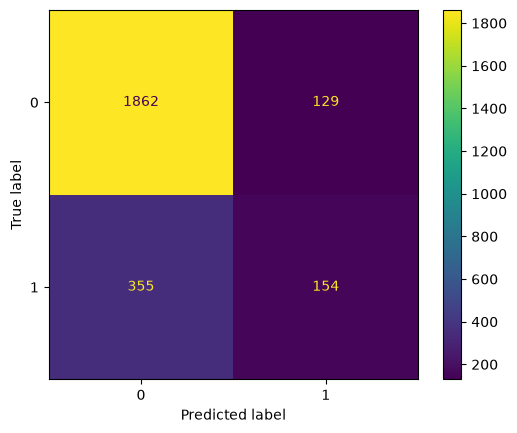

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler

churn_df = pd.read_csv('Churn_Modelling.csv')

churn_df = churn_df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Gender'])

churn_df['Exited'].value_counts()

churn_df['Loyalty'] = churn_df['Tenure']/churn_df['Age']
churn_df = churn_df.drop(columns=['Tenure', 'Age'])
churn_df.head()

churn_df['Geography'].unique()
churn_df = pd.get_dummies(churn_df, columns=['Geography'], drop_first=True)
churn_df.head()

# Define the y (target) variable
# 1. Tách nhãn cần dự đoán (Target variable - y)
# Cột 'Exited' chứa nhãn: 0 (Khách hàng ở lại) hoặc 1 (Khách hàng rời bỏ)
y = churn_df['Exited']

# Define the X (predictor) variables
# 2. Tạo tập biến đặc trưng đầu vào (Predictor variables / Features - X)
X = churn_df.copy()
X = X.drop('Exited', axis=1)

# Split into train and test sets
# 3. Chia dữ liệu thành tập huấn luyện (Train: 75%) và kiểm thử (Test: 25%)
# - test_size=0.25: Dành 25% dữ liệu làm tập test, 75% còn lại để train
# - stratify=y: Đảm bảo tỷ lệ nhãn 0 và 1 ở cả 2 tập train/test bằng đúng tỷ lệ gốc
# - random_state=42: Cố định hạt giống ngẫu nhiên để kết quả chia luôn nhất quán mỗi lần chạy

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, \
                                                    stratify=y, random_state=42)


X.describe()

# Instantiate the scaler
scaler = MinMaxScaler()

# Fit the scaler to the training data
scaler.fit(X_train)

# Scale the training data
X_train = scaler.transform(X_train)

# Scale the test data
X_test = scaler.transform(X_test)

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train, y_train)

# Get the predictions on test data
scaled_preds = gnb_scaled.predict(X_test)

print('Accuracy:', '%.3f' % accuracy_score(y_test, scaled_preds))
print('Precision:', '%.3f' % precision_score(y_test,scaled_preds))
print('Recall:', '%.3f' % recall_score(y_test, scaled_preds))
print('F1 Score:', '%.3f' % f1_score(y_test, scaled_preds))

def conf_matrix_plot(model, x_data, y_data):
    '''
    Accepts as argument model object, X data (test or validate), and y data (test or validate). 
    Return a plot of confusion matrix for predictions on y data.
    ''' 
  
    model_pred = model.predict(x_data)
    cm = confusion_matrix(y_data, model_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_,
                                 )
  
    disp.plot(values_format='') # `values_format=''` suppresses scientific notation
    plt.show()

conf_matrix_plot(gnb_scaled, X_test, y_test)